In [10]:
!pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

wb = openpyxl.load_workbook('./superstore.xlsx')
print(wb.sheetnames)
data = pd.read_excel('./superstore.xlsx', sheet_name=0)
print(data.describe())
print(data.sample(10))


['Orders', 'People', 'Returns']
             Row ID                     Order Date  \
count  10194.000000                          10194   
mean    5097.500000  2025-04-29 11:48:25.002942720   
min        1.000000            2023-01-03 00:00:00   
25%     2549.250000            2024-05-14 00:00:00   
50%     5097.500000            2025-06-25 00:00:00   
75%     7645.750000            2026-05-14 00:00:00   
max    10194.000000            2026-12-30 00:00:00   
std     2942.898656                            NaN   

                           Ship Date         Sales      Quantity  \
count                          10194  10194.000000  10194.000000   
mean   2025-05-03 10:52:45.626839296    228.225854      3.791838   
min              2023-01-07 00:00:00      0.444000      1.000000   
25%              2024-05-19 00:00:00     17.220000      2.000000   
50%              2025-06-28 00:00:00     53.910000      3.000000   
75%              2026-05-18 00:00:00    209.500000      5.000000   
max  

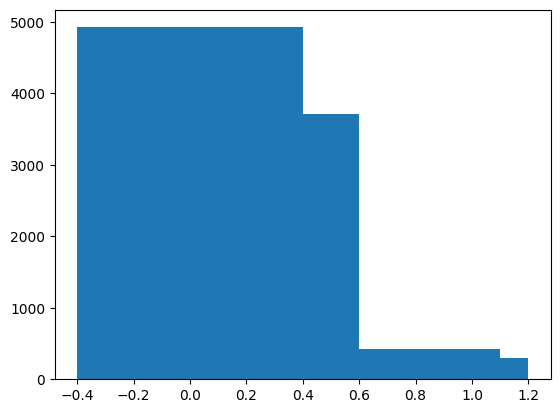

In [12]:
# data["Discount"].value_counts().plot(kind='bar') #value counts is used to count 
                #the number of occurrences of each unique value in a column. In this case, 
                # it counts the number of occurrences of each unique value in the "Discount" column of 
                # the data DataFrame. The resulting counts are then plotted as a bar chart using the plot()
                #  function with kind='bar'.
plt.bar(data["Discount"].value_counts().index, data["Discount"].value_counts().values)
plt.show()


In [13]:
data.isnull() #isnull() is used to check for missing values in the DataFrame.

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10190,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10191,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10192,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
data_new= data.rename(columns={"Discount":"Discounts"},inplace=False)
data_new.head() #head() is used to display the first few rows of the DataFrame.

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discounts,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [15]:
data_new.dropna(axis=0, )
data_new.drop([0,2,90],inplace=True)
print(data_new)

       Row ID        Order ID Order Date  Ship Date       Ship Mode  \
1           2  US-2023-112326 2023-01-04 2023-01-08  Standard Class   
3           4  US-2023-112326 2023-01-04 2023-01-08  Standard Class   
4           5  US-2023-141817 2023-01-05 2023-01-12  Standard Class   
5           6  US-2023-167199 2023-01-06 2023-01-10  Standard Class   
6           7  US-2023-167199 2023-01-06 2023-01-10  Standard Class   
...       ...             ...        ...        ...             ...   
10189   10190  US-2026-143259 2026-12-30 2027-01-03  Standard Class   
10190   10191  US-2026-115427 2026-12-30 2027-01-03  Standard Class   
10191   10192  US-2026-156720 2026-12-30 2027-01-03  Standard Class   
10192   10193  US-2026-143259 2026-12-30 2027-01-03  Standard Class   
10193   10194  CA-2026-143500 2026-12-30 2027-01-03  Standard Class   

      Customer ID      Customer Name      Segment Country/Region  \
1        PO-19195      Phillina Ober  Home Office  United States   
3        PO

In [16]:
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

<Axes: xlabel='Category'>

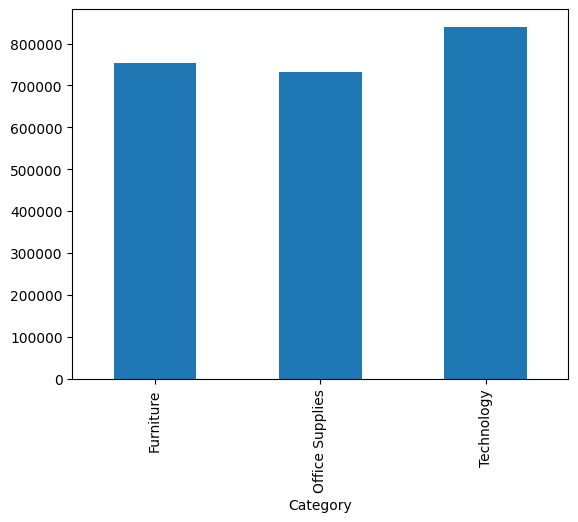

In [17]:
data.groupby("Category")["Sales"].sum().plot(kind='bar')

In [18]:
data2 = pd.read_excel('./superstore.xlsx', sheet_name=1) #for importing people data
print(data2.sample(4))


    Regional Manager   Region
2  Roxanne Rodriguez  Central
0    Sadie Pawthorne     West
3        Fred Suzuki    South
1        Chuck Magee     East


In [21]:
data3=data2.merge(data_new, on = "Region", how='inner') #concat() is used to concatenate two or more DataFrames along a particular axis.
data3
# data3.query("`Regional Manager` == 'Fred Suzuki'")

,Regional Manager,Region,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,...,State/Province,Postal Code,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discounts,Profit
0,Sadie Pawthorne,West,12,US-2023-130813,2023-01-06,2023-01-08,Second Class,LS-17230,Lycoris Saunders,Consumer,...,California,90049,OFF-PA-10002005,Office Supplies,Paper,Xerox 225,19.440,3,0.00,9.3312
1,Sadie Pawthorne,West,22,US-2023-157147,2023-01-13,2023-01-18,Standard Class,BD-11605,Brian Dahlen,Consumer,...,California,94109,FUR-BO-10003034,Furniture,Bookcases,"O'Sullivan Elevations Bookcase, Cherry Finish",333.999,3,0.15,3.9294
2,Sadie Pawthorne,West,24,US-2023-157147,2023-01-13,2023-01-18,Standard Class,BD-11605,Brian Dahlen,Consumer,...,California,94109,OFF-AR-10003514,Office Supplies,Art,4009 Highlighters by Sanford,19.900,5,0.00,6.5670
3,Sadie Pawthorne,West,31,US-2023-157147,2023-01-13,2023-01-18,Standard Class,BD-11605,Brian Dahlen,Consumer,...,California,94109,OFF-ST-10000078,Office Supplies,Storage,Tennsco 6- and 18-Compartment Lockers,1325.850,5,0.00,238.6530
4,Sadie Pawthorne,West,39,US-2023-123477,2023-01-18,2023-01-21,Second Class,DW-13195,David Wiener,Corporate,...,Oregon,97477,OFF-AP-10000692,Office Supplies,Appliances,Fellowes Mighty 8 Compact Surge Protector,64.864,4,0.20,6.4864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10186,Fred Suzuki,South,10172,US-2026-158526,2026-12-29,2027-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,...,Kentucky,40214,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,258.750,3,0.00,77.6250
10187,Fred Suzuki,South,10173,US-2026-158526,2026-12-29,2027-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,...,Kentucky,40214,FUR-CH-10002602,Furniture,Chairs,DMI Arturo Collection Mission-style Design Woo...,1207.840,8,0.00,314.0384
10188,Fred Suzuki,South,10175,US-2026-158526,2026-12-29,2027-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,...,Kentucky,40214,FUR-CH-10004495,Furniture,Chairs,"Global Leather and Oak Executive Chair, Black",300.980,1,0.00,87.2842
10189,Fred Suzuki,South,10178,US-2026-158526,2026-12-29,2027-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,...,Kentucky,40214,OFF-AR-10003696,Office Supplies,Art,Panasonic KP-350BK Electric Pencil Sharpener w...,34.580,1,0.00,10.0282


In [20]:
data3["Regional Manager"] = data3["Regional Manager"].str.strip()
data4=data3["Regional Manager"].map({"Fred Suzuki": "FS", "Sadie Pawthorne": "SP", "Roxanne Rodriguez": "RR"}) 
#here map() returns a series with the same index as the original series, replacing the values according to the mapping provided. 
# In this case, it replaces the values in the "Regional Manager" column of the data3 DataFrame with their corresponding abbreviations as defined in the mapping dictionary.
print(data4)
print(data3["Regional Manager"].dtype)

0        RR
1        RR
2        RR
3        RR
4        RR
         ..
10186    SP
10187    SP
10188    SP
10189    SP
10190    SP
Name: Regional Manager, Length: 10191, dtype: object
object


In [24]:
data3["Year"]=data3["Order Date"].dt.year
data3["Month"]=data3["Order Date"].dt.month
data3["Day"]=data3["Order Date"].dt.day
data3["Day of Week"]=data3["Order Date"].dt.day_of_week
data3["Quarter"]=data3["Order Date"].dt.quarter
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
     3: "Spring", 4: "Spring", 5: "Spring",
     6: "Summer", 7: "Summer", 8: "Summer",
     9: "Autumn",10: "Autumn",11: "Autumn"
}
data3["Season"] = data3["Month"].map(season_map)
data3

,Regional Manager,Region,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,...,Sales,Quantity,Discounts,Profit,Year,Month,Day,Day of Week,Quarter,Season
0,Sadie Pawthorne,West,12,US-2023-130813,2023-01-06,2023-01-08,Second Class,LS-17230,Lycoris Saunders,Consumer,...,19.440,3,0.00,9.3312,2023,1,6,4,1,Winter
1,Sadie Pawthorne,West,22,US-2023-157147,2023-01-13,2023-01-18,Standard Class,BD-11605,Brian Dahlen,Consumer,...,333.999,3,0.15,3.9294,2023,1,13,4,1,Winter
2,Sadie Pawthorne,West,24,US-2023-157147,2023-01-13,2023-01-18,Standard Class,BD-11605,Brian Dahlen,Consumer,...,19.900,5,0.00,6.5670,2023,1,13,4,1,Winter
3,Sadie Pawthorne,West,31,US-2023-157147,2023-01-13,2023-01-18,Standard Class,BD-11605,Brian Dahlen,Consumer,...,1325.850,5,0.00,238.6530,2023,1,13,4,1,Winter
4,Sadie Pawthorne,West,39,US-2023-123477,2023-01-18,2023-01-21,Second Class,DW-13195,David Wiener,Corporate,...,64.864,4,0.20,6.4864,2023,1,18,2,1,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10186,Fred Suzuki,South,10172,US-2026-158526,2026-12-29,2027-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,...,258.750,3,0.00,77.6250,2026,12,29,1,4,Winter
10187,Fred Suzuki,South,10173,US-2026-158526,2026-12-29,2027-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,...,1207.840,8,0.00,314.0384,2026,12,29,1,4,Winter
10188,Fred Suzuki,South,10175,US-2026-158526,2026-12-29,2027-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,...,300.980,1,0.00,87.2842,2026,12,29,1,4,Winter
10189,Fred Suzuki,South,10178,US-2026-158526,2026-12-29,2027-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,...,34.580,1,0.00,10.0282,2026,12,29,1,4,Winter
